In [1]:
import torch
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt

from dataset import NNUEIterableDataset

In [2]:
dataloader = DataLoader(
    NNUEIterableDataset("/home/fausto/myProjects/HarukaShogi/data/nnue/dataset_v0/val",
                        batch_size=16384, random_hflip=False, hflip=False),
    batch_size=None,
    num_workers=8,
    persistent_workers=True,
    prefetch_factor=4,
)

# flip_dataloader = DataLoader(
#     NNUEIterableDataset("../data/test_binps", batch_size=1000, random_hflip=False, hflip=True),
#     batch_size=None,
#     num_workers=2,
#     persistent_workers=True,
#     prefetch_factor=4,
# )

In [3]:
buckets = np.linspace(-10000, 10000, 100)
counts = np.zeros(100)
wins = np.zeros(100)

idx_counts = np.zeros(2344)

# for (batch, flip_batch) in zip(dataloader, flip_dataloader):
for batch in dataloader:
    b, w, s, r, t = batch

    # flip_b, flip_w, flip_s, flip_r, flip_t = flip_batch

    # b = torch.cat([b, flip_b], dim=0)
    # w = torch.cat([w, flip_w], dim=0)
    # s = torch.cat([s, flip_s], dim=0)
    # r = torch.cat([r, flip_r], dim=0)
    # t = torch.cat([t, flip_t], dim=0)

    np.add.at(idx_counts, b.flatten(), 1)
    np.add.at(idx_counts, w.flatten(), 1)

    s = np.clip(s, -10000, 10000)

    # digitize returns the indices of the buckets [1, ..., len(buckets)]
    bin_indices = np.digitize(s, buckets) - 1  # Shift to zero-indexed

    # keep only scores that fell within the buckets
    mask = (bin_indices >= 0) & (bin_indices < len(buckets))
    bin_indices = bin_indices[mask]
    r_valid = r[mask]

    # Update counts and wins per bucket
    # for idx, result in zip(bin_indices, r_valid):
    #     counts[idx] += 1
    #     wins[idx] += result
    counts += np.bincount(bin_indices, minlength=len(buckets))
    wins += np.bincount(bin_indices, weights=r_valid, minlength=len(buckets))

# total = counts.sum() / 2 # remove the flip counts
total = counts.sum()
print(f'total: {total.item()}')

perf = wins / counts

total: 13347659.0


In [4]:
buckets = buckets / (127*64)

In [5]:
targets = torch.sigmoid(torch.tensor(buckets*3)).numpy()

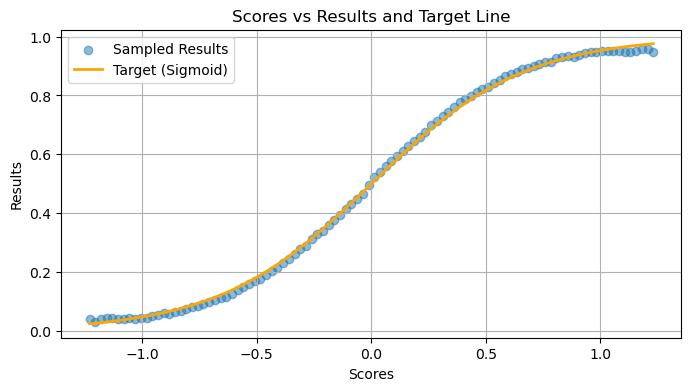

In [6]:
plt.figure(figsize=(8, 4))
plt.scatter(buckets, perf, alpha=0.5, label='Sampled Results')
plt.plot(buckets, targets, color='orange', label='Target (Sigmoid)', linewidth=2)

plt.xlabel('Scores')
plt.ylabel('Results')
plt.title('Scores vs Results and Target Line')
# plt.xlim(-10000, 10000)
plt.grid(True)
plt.legend()
plt.show()

In [7]:
empty_idxs = np.where(idx_counts == 0)[0]
print(f'{empty_idxs.shape[0]} empty features')
print(f'{empty_idxs.shape[0] - (9*4*2)} after removing impossible features')
for idx in empty_idxs:
    print(idx)


176 empty features
104 after removing impossible features
243
244
245
246
247
248
249
250
251
324
325
326
327
328
329
330
331
332
333
334
335
336
337
338
339
340
341
567
568
569
570
571
572
573
574
575
711
712
714
715
716
717
719
720
721
722
723
724
725
726
727
728
785
787
793
795
796
800
803
804
805
806
807
808
809
873
875
876
877
878
882
883
884
885
886
887
889
890
1118
1120
1121
1126
1127
1128
1129
1130
1131
1449
1450
1451
1452
1453
1454
1455
1456
1457
1521
1522
1523
1524
1525
1526
1527
1528
1529
1530
1531
1532
1533
1534
1535
1536
1537
1538
1773
1774
1775
1776
1777
1778
1779
1780
1781
1782
1783
1784
1785
1786
1787
1788
1789
1790
1791
1793
1794
1795
1796
1798
1799
1863
1864
1865
1866
1867
1868
1869
1872
1876
1877
1879
1885
1887
1944
1945
1947
1948
1949
1950
1951
1952
1956
1957
1958
1959
1961
2189
2190
2191
2192
2193
2194
2199
2200
2202
2305
2343
